<a href="https://colab.research.google.com/github/P-SAM-SAHIL/alc_newspaper_proj/blob/main/Proj_Newspaper_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part-1 Analysis

In [ ]:
!pip install gdown

In [ ]:

import gdown
import pandas as pd

file_id = "17lL06dXXGV_-AuEui8c6WI4WMExQVwt2"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "data.csv", quiet=False)

df = pd.read_csv("data.csv")
df.head()

Downloading...
From (original): https://drive.google.com/uc?id=17lL06dXXGV_-AuEui8c6WI4WMExQVwt2
From (redirected): https://drive.google.com/uc?id=17lL06dXXGV_-AuEui8c6WI4WMExQVwt2&confirm=t&uuid=941ce597-5a83-4450-8b0e-b57fc2944335
To: /content/data.csv
100%|██████████| 497M/497M [00:08<00:00, 58.6MB/s]


,article_id,date,newspaper_name,headline,article,LCCN,State,County,City
0,3_1963-12-15_p23_sn83045462_00280609249_196312...,1963-12-15,"Evening star. [volume] (Washington, D.C.) 1854...",Air Pollution,Both House and Senate last\nweek also cleared ...,sn83045462,District of Columbia,NaN,Washington
1,4_1963-12-15_p23_sn83045462_00280609249_196312...,1963-12-15,"Evening star. [volume] (Washington, D.C.) 1854...",THE WEEK IN PERSPECTIVE\nOn Spending and Politics,President Johnson drove ahead\non his economy ...,sn83045462,District of Columbia,NaN,Washington
2,5_1963-12-15_p23_sn83045462_00280609249_196312...,1963-12-15,"Evening star. [volume] (Washington, D.C.) 1854...",Succession::\nNew SYSTEM?,"The fact that House Speaker\nMccormack, ~, and...",sn83045462,District of Columbia,NaN,Washington
3,6_1963-12-15_p23_sn83045462_00280609249_196312...,1963-12-15,"Evening star. [volume] (Washington, D.C.) 1854...",Congress-:\n\n\nAid Watchdog,The foreign-aid program suf-\n\n\nfered the de...,sn83045462,District of Columbia,NaN,Washington
4,7_1963-12-15_p23_sn83045462_00280609249_196312...,1963-12-15,"Evening star. [volume] (Washington, D.C.) 1854...",More Incentive,Many Americans would say that\nincentive rathe...,sn83045462,District of Columbia,NaN,Washington


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Load dataset
# -----------------------------
df = pd.read_csv("data.csv")

# -----------------------------
# 2. Convert date and extract month
# -----------------------------
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["month"] = df["date"].dt.to_period("M").astype(str)

# -----------------------------
# 3. Calculate frequencies
# -----------------------------
county_month = df.groupby(["County", "month"], dropna=False).size().reset_index(name="frequency")
state_month = df.groupby(["State", "month"], dropna=False).size().reset_index(name="frequency")
newspaper_month = df.groupby(["newspaper_name", "month"], dropna=False).size().reset_index(name="frequency")

# -----------------------------
# 4. Save aggregated CSVs
# -----------------------------
county_month.to_csv("county_month_frequencies.csv", index=False)
state_month.to_csv("state_month_frequencies.csv", index=False)
newspaper_month.to_csv("newspaper_month_frequencies.csv", index=False)

# -----------------------------
# 5. Visualization function
# -----------------------------
def plot_time_series(data, entity_col, title, filename):

    pivot = data.pivot(index="month", columns=entity_col, values="frequency").fillna(0)

    plt.figure(figsize=(14,6))

    for col in pivot.columns:
        plt.plot(pivot.index, pivot[col], label=str(col), linewidth=1)

    plt.xticks(rotation=45)
    plt.xlabel("Month")
    plt.ylabel("Article Frequency")
    plt.title(title)

    # Too many labels -> move legend outside
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.close()

# -----------------------------
# 6. Generate plots
# -----------------------------
plot_time_series(
    county_month,
    "County",
    "Monthly Article Frequency by County",
    "county_frequency_timeseries.png"
)

plot_time_series(
    state_month,
    "State",
    "Monthly Article Frequency by State",
    "state_frequency_timeseries.png"
)

plot_time_series(
    newspaper_month,
    "newspaper_name",
    "Monthly Article Frequency by Newspaper",
    "newspaper_frequency_timeseries.png"
)

# -----------------------------
# 7. Preview
# -----------------------------
print(county_month.head())
print(state_month.head())
print(newspaper_month.head())

print("Visualizations saved successfully.")

      County    month  frequency
0  Anchorage  1963-01        142
1  Anchorage  1963-02        127
2  Anchorage  1963-03        128
3  Anchorage  1963-04        149
4  Anchorage  1963-05        135
     State    month  frequency
0  Alabama  1963-01         20
1  Alabama  1963-02         22
2  Alabama  1963-03         16
3  Alabama  1963-04         20
4  Alabama  1963-05         24
      newspaper_name    month  frequency
0  Apache drum beat.  1963-01         48
1  Apache drum beat.  1963-02         46
2  Apache drum beat.  1963-03         69
3  Apache drum beat.  1963-04         36
4  Apache drum beat.  1963-05         40
Visualizations saved successfully.


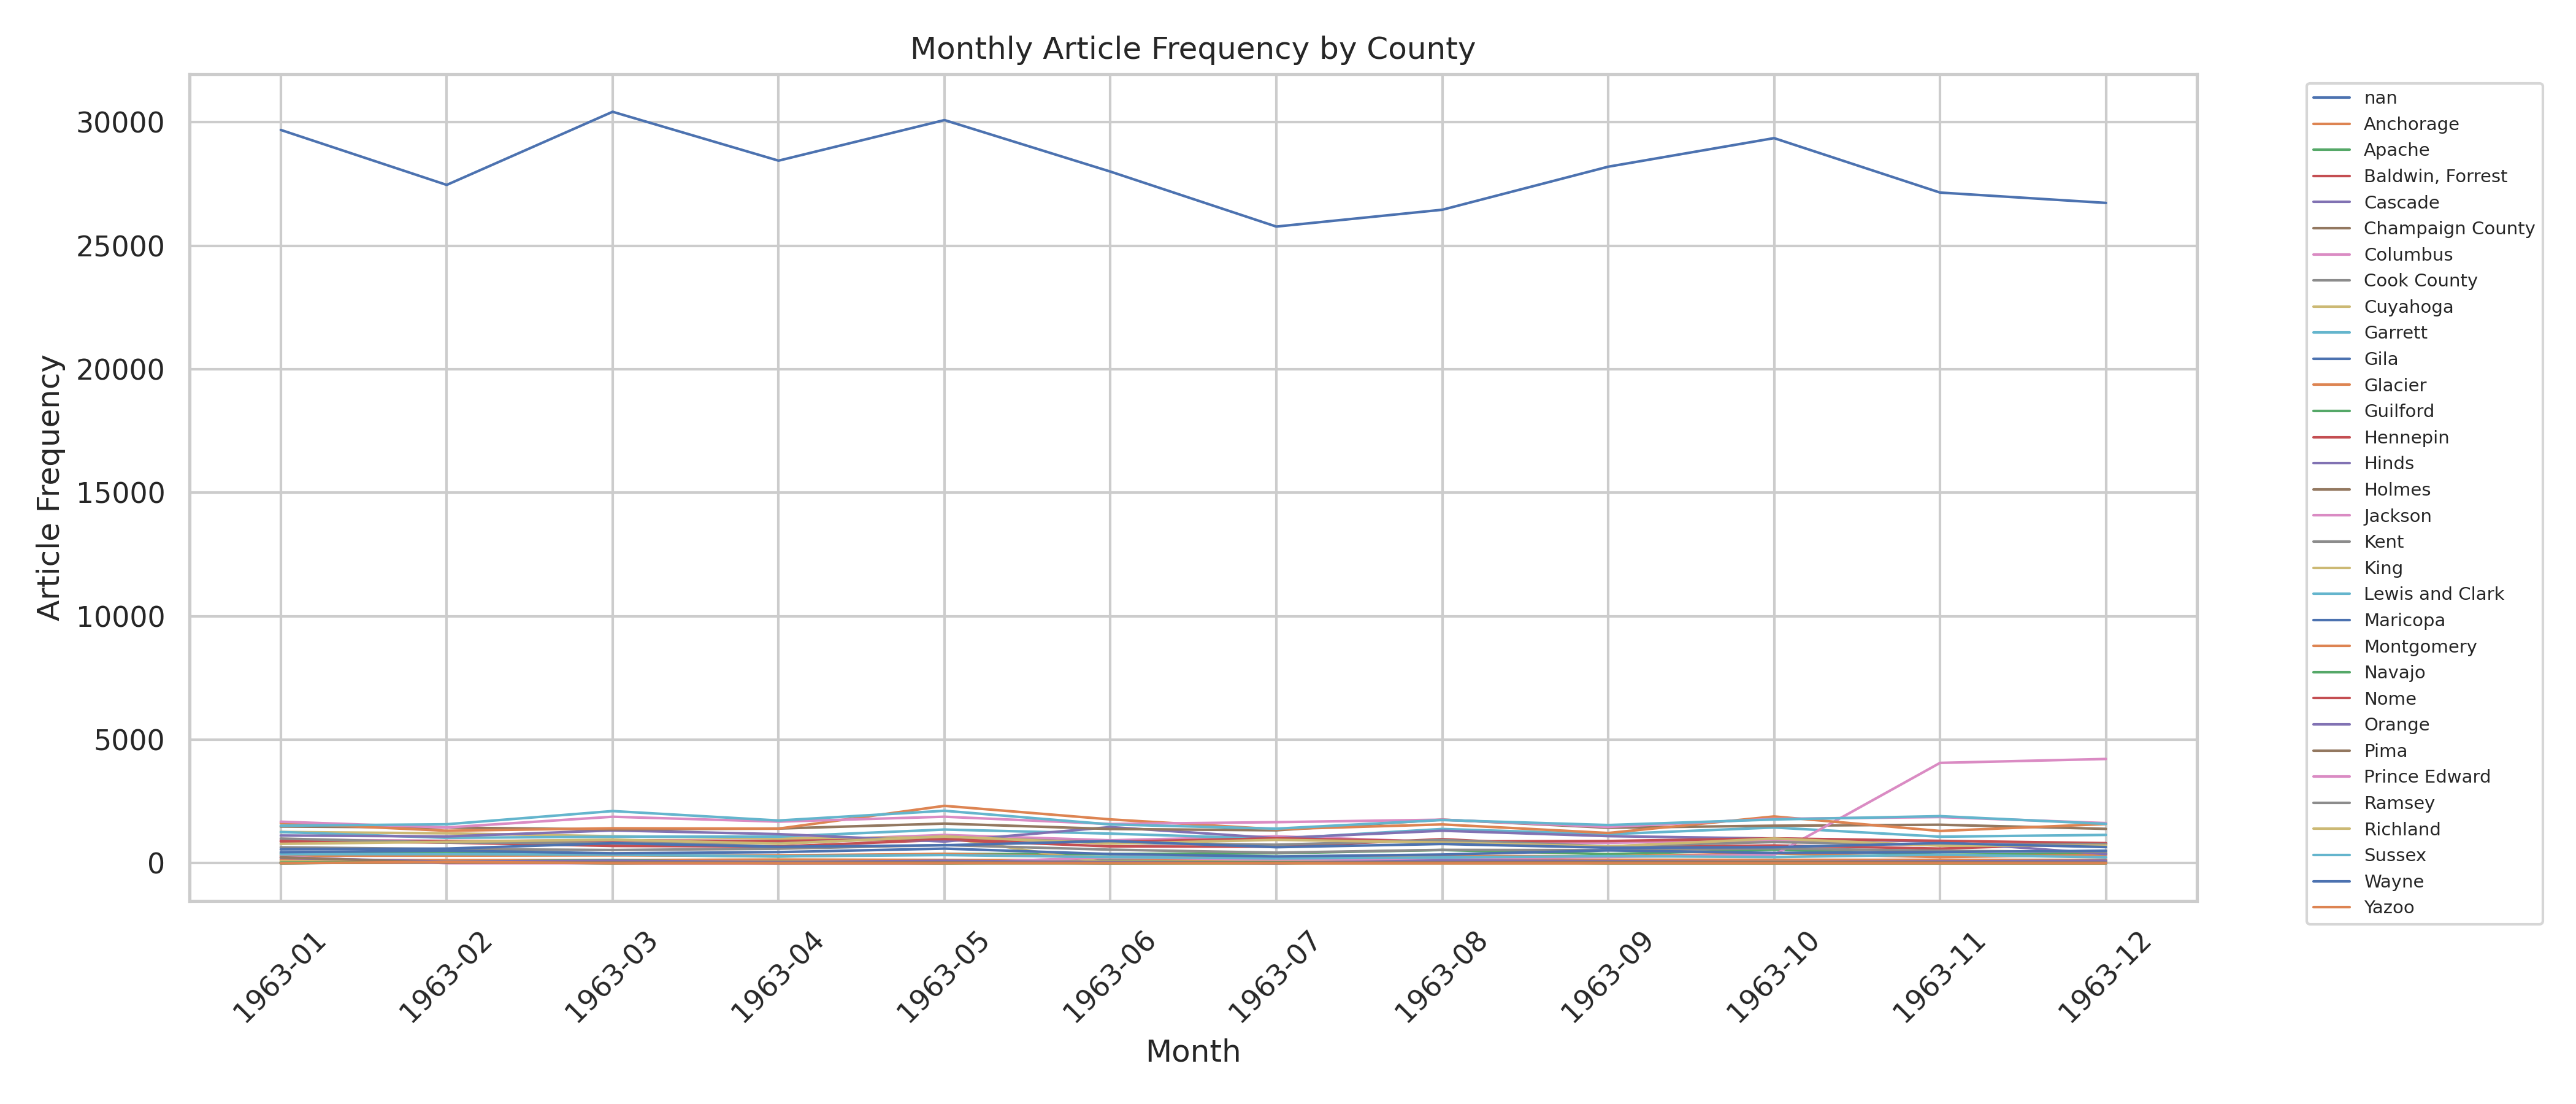

In [ ]:
from IPython.display import Image
Image(filename='county_frequency_timeseries.png')

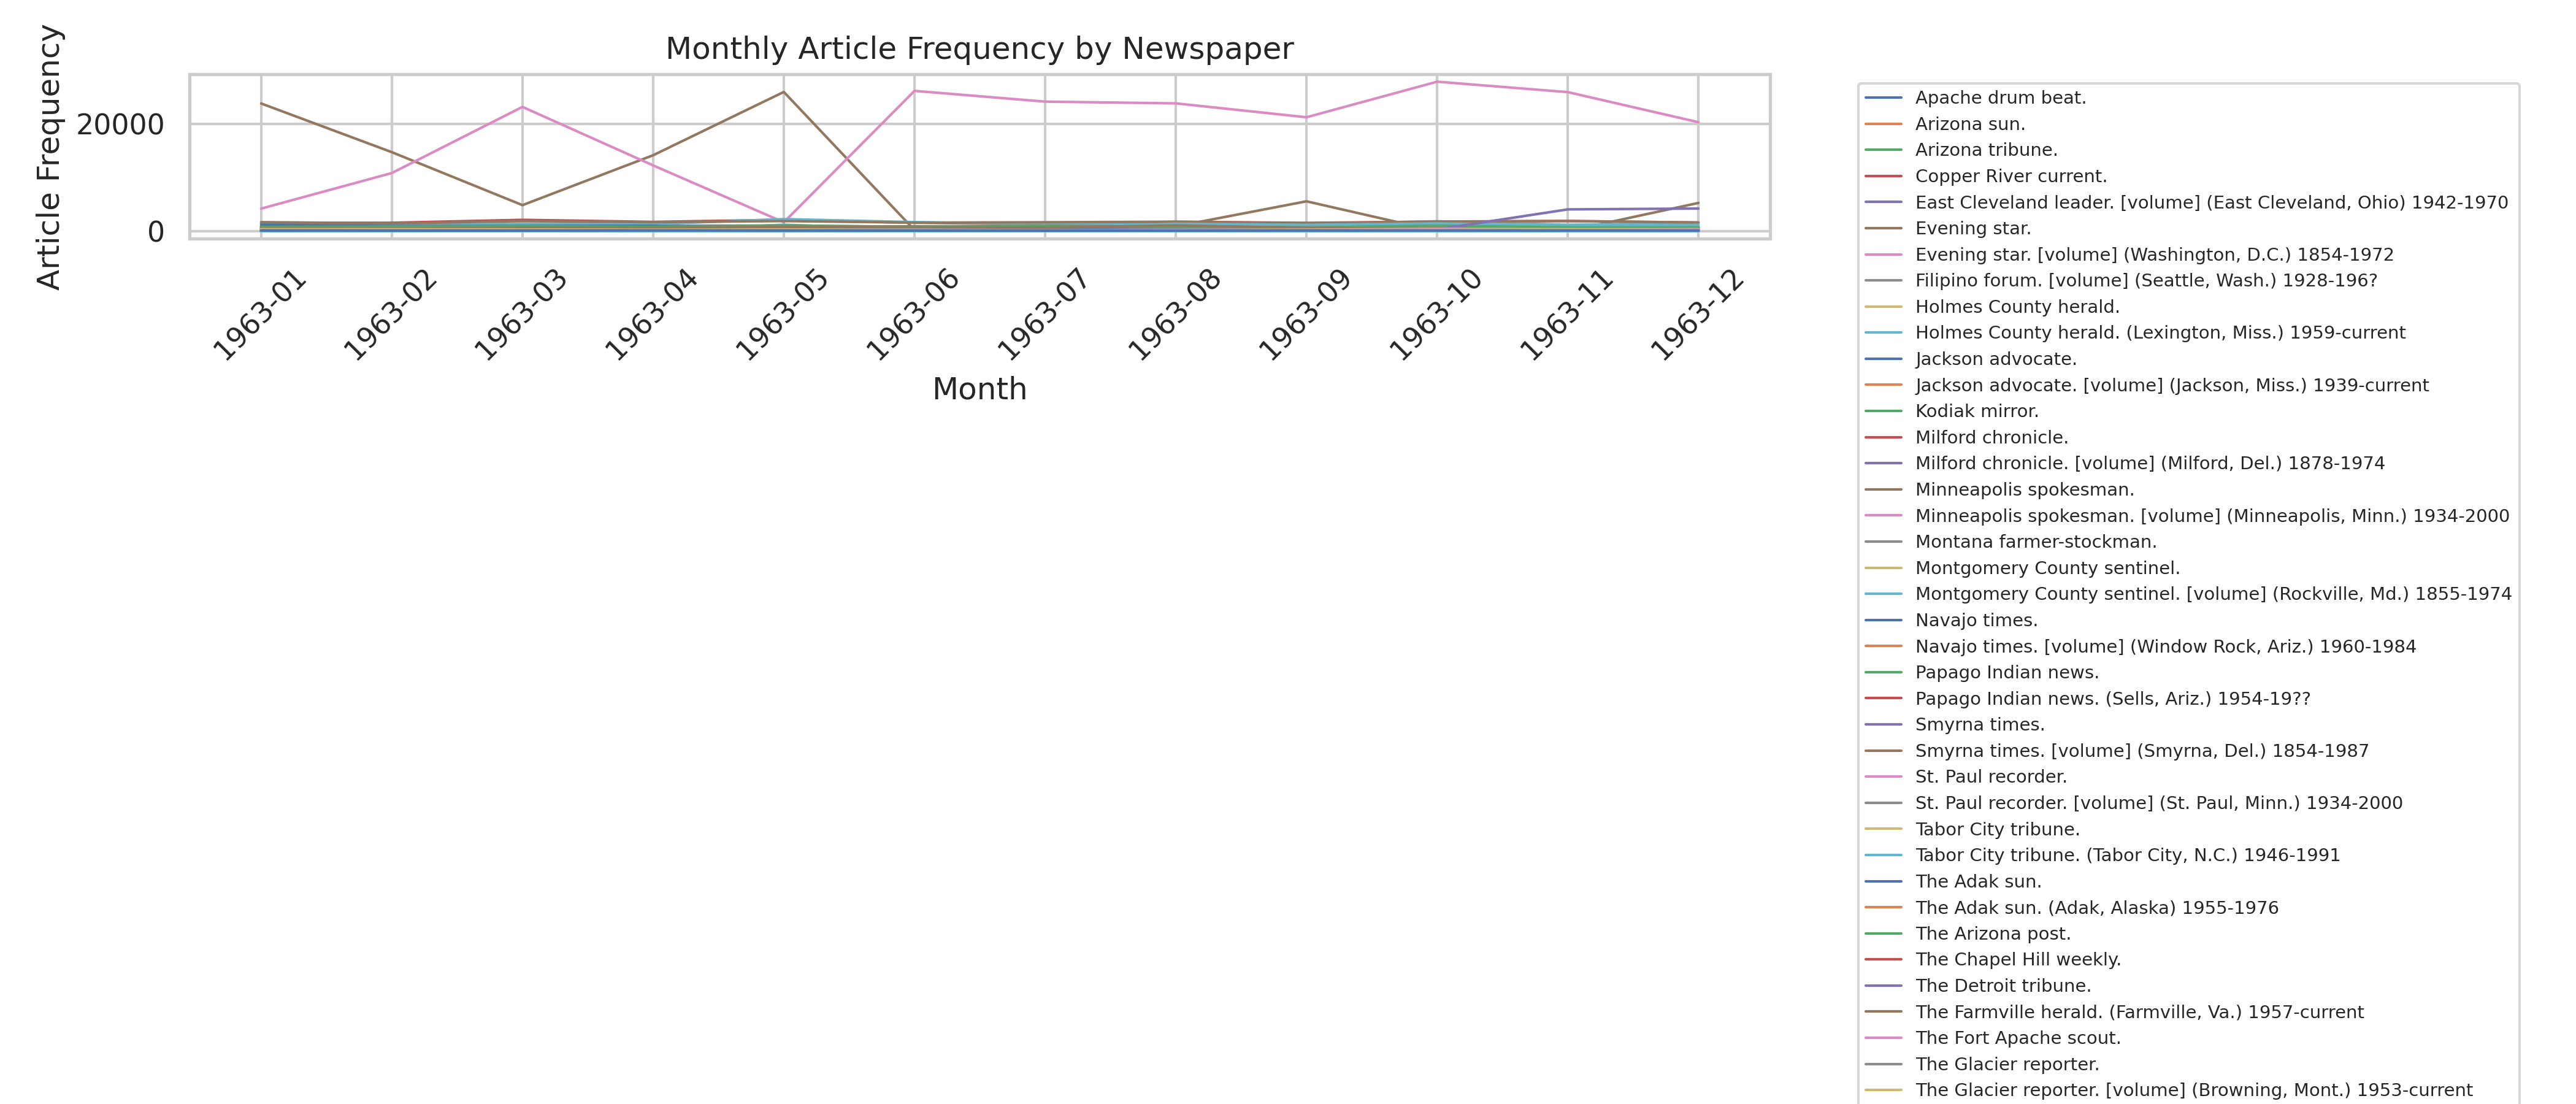

In [ ]:

Image(filename='newspaper_frequency_timeseries.png')

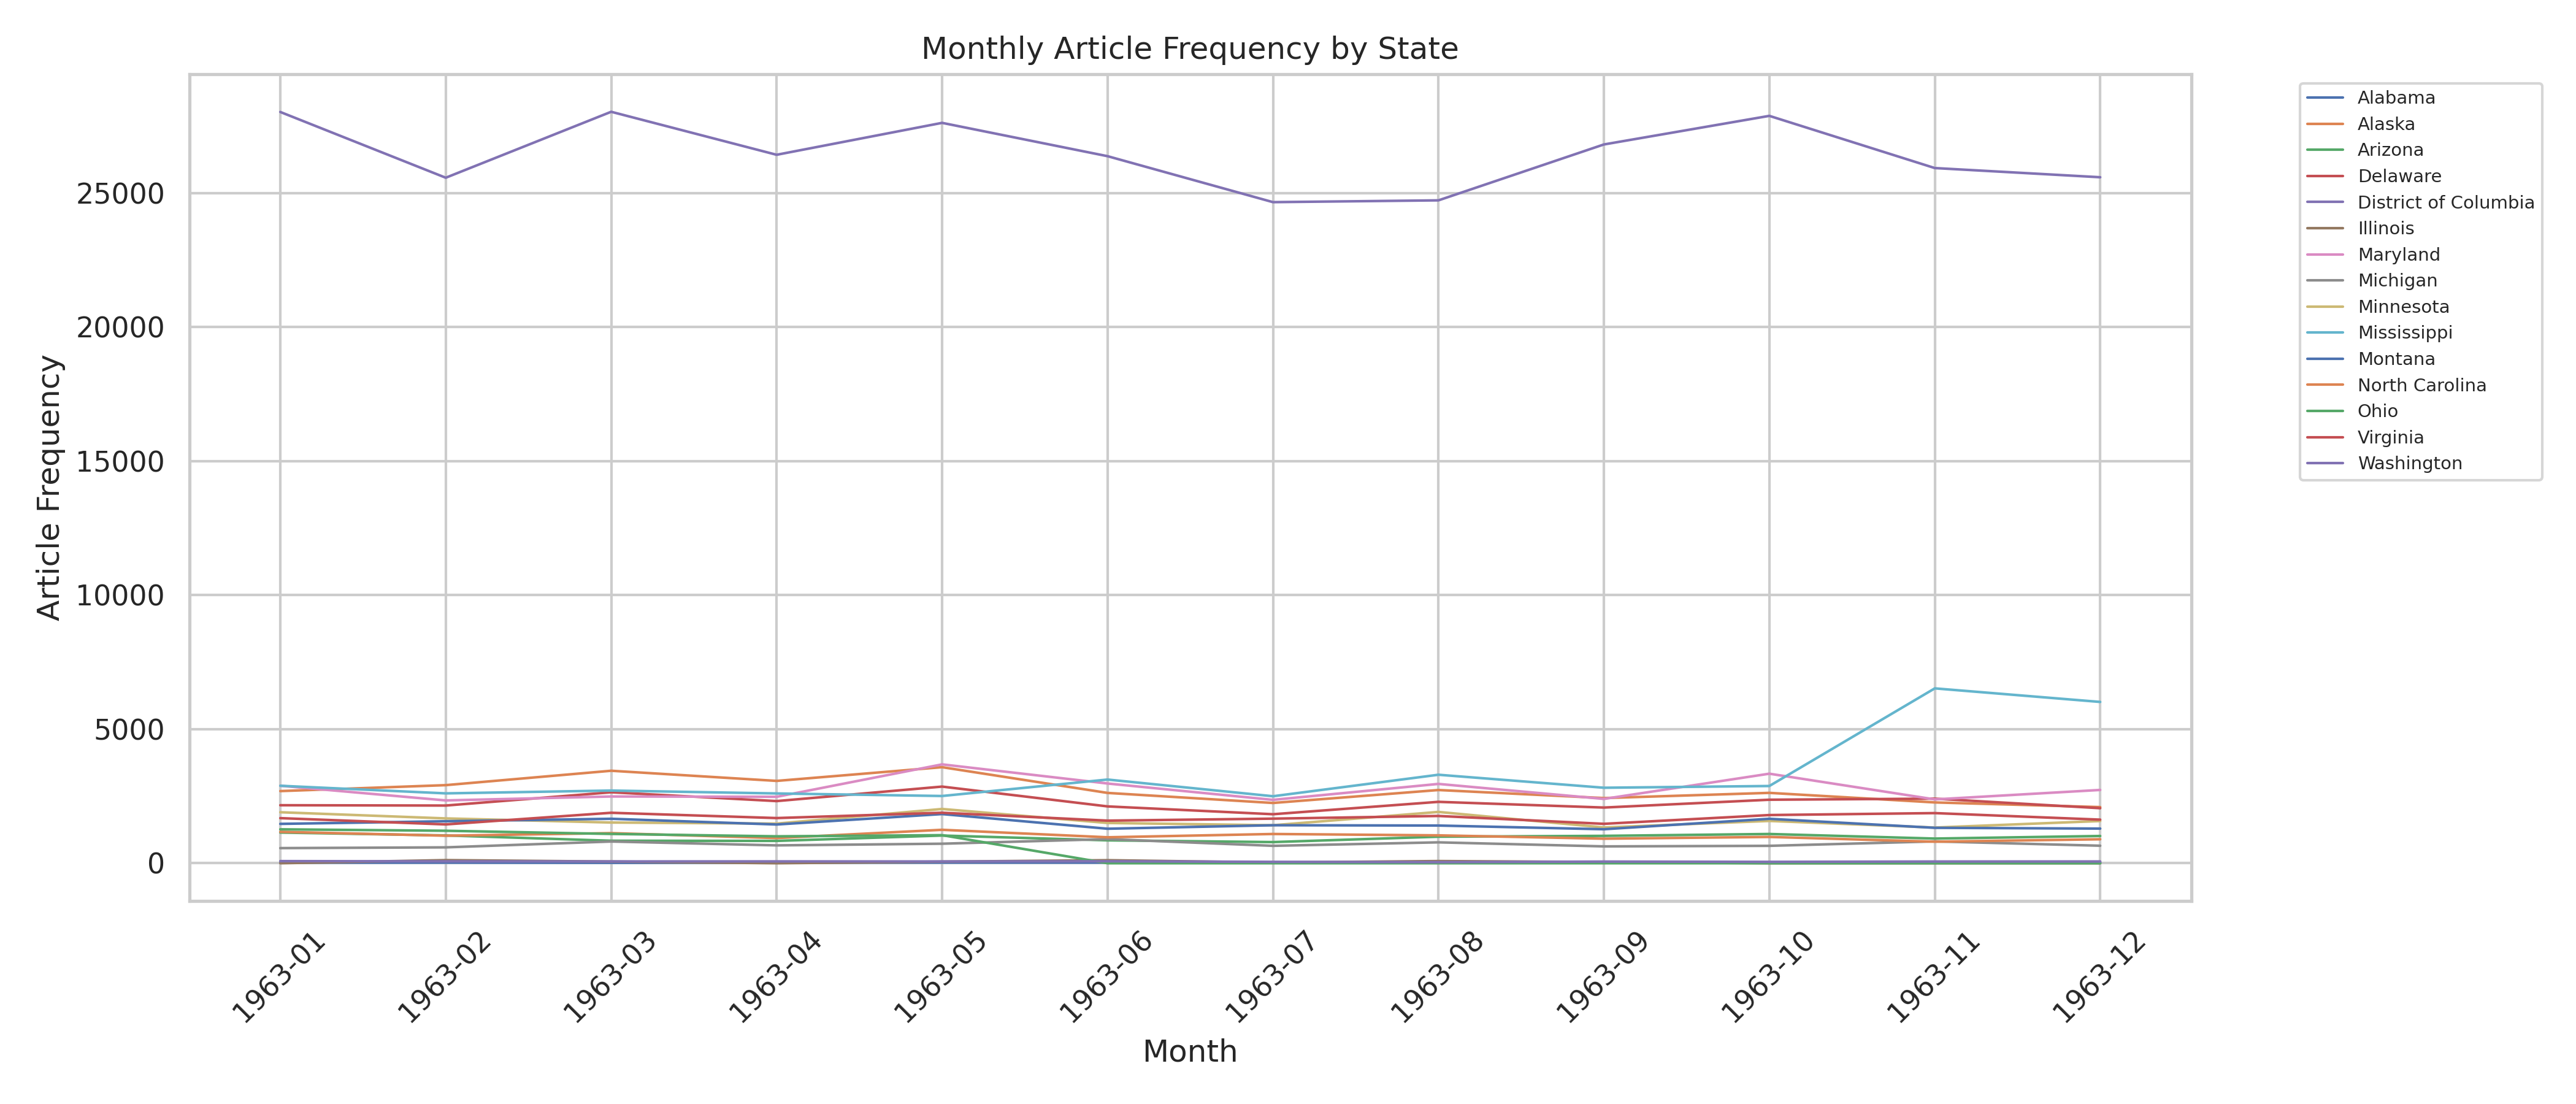

In [ ]:

Image(filename='state_frequency_timeseries.png')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 547783 entries, 0 to 547782
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   article_id      547783 non-null  object        
 1   date            547783 non-null  datetime64[ns]
 2   newspaper_name  547783 non-null  object        
 3   headline        322882 non-null  object        
 4   article         547783 non-null  object        
 5   LCCN            547783 non-null  object        
 6   State           547783 non-null  object        
 7   County          209947 non-null  object        
 8   City            547783 non-null  object        
 9   month           547783 non-null  object        
dtypes: datetime64[ns](1), object(9)
memory usage: 41.8+ MB


In [ ]:
df_master=pd.read_csv("/content/chronicling-america.csv")
df_master.head()

,Newspapers,LCCN,OCLC,ISSN,State,County,City,Geo Location,Browse Digitized Issues,Number of Issues,First Issue,Last Issue,Essay Available,Languages,Ethnicity
0,"The Abbeville Banner (Abbeville, S.C.) 1847-1869",sn85026945,12795764,2373-1370,South Carolina,Abbeville,Abbeville,"34.179102, -82.3777663",https://www.loc.gov/item/sn85026945/?st=calendar,254.0,1847-03-03,1869-09-29,True,English,NaN
1,"The Abbeville Bulletin (Abbeville, S.C.) 1865-...",sn93067670,27841255,2375-0111,South Carolina,Abbeville,Abbeville,"34.179102, -82.3777663",https://www.loc.gov/item/sn93067670/?st=calendar,4.0,1865-08-10,1865-08-31,True,English,NaN
2,"The Abbeville Messenger (Abbeville, S.C.) 1884...",sn93067668,27841291,2375-0081,South Carolina,Abbeville,Abbeville,"34.179102, -82.3777663",https://www.loc.gov/item/sn93067668/?st=calendar,109.0,1884-10-01,1887-02-08,True,English,NaN
3,"Abbeville Press (Abbeville, S.C.) 1860-1869",sn85042527,12622573,2373-3535,South Carolina,Abbeville,Abbeville,"34.179102, -82.3777663",https://www.loc.gov/item/sn85042527/?st=calendar,275.0,1860-11-09,1869-09-24,True,English,NaN
4,"The Abbeville Press and Banner (Abbeville, S.C...",sn84026853,10708843,2372-6768,South Carolina,Abbeville,Abbeville,"34.179102, -82.3777663",https://www.loc.gov/item/sn84026853/?st=calendar,3090.0,1869-10-01,1923-05-30,True,English,NaN


In [ ]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4709 entries, 0 to 4708
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Newspapers               4709 non-null   object 
 1   LCCN                     4709 non-null   object 
 2   OCLC                     4709 non-null   object 
 3   ISSN                     4195 non-null   object 
 4   State                    4708 non-null   object 
 5   County                   4397 non-null   object 
 6   City                     4704 non-null   object 
 7   Geo Location             4708 non-null   object 
 8   Browse Digitized Issues  4708 non-null   object 
 9   Number of Issues         4708 non-null   float64
 10  First Issue              4708 non-null   object 
 11  Last Issue               4708 non-null   object 
 12  Essay Available          4196 non-null   object 
 13  Languages                4709 non-null   object 
 14  Ethnicity               

In [ ]:
 df_master[df_master['County'].isna()]



,Newspapers,LCCN,OCLC,ISSN,State,County,City,Geo Location,Browse Digitized Issues,Number of Issues,First Issue,Last Issue,Essay Available,Languages,Ethnicity
19,"The Adak Daily Sun (Adak, Alaska) 19??-1954",sn97060075,38055220,2993-8805,Alaska,NaN,Adak,"51.873021, -176.660875",https://www.loc.gov/item/sn97060075/?st=calendar,1.0,1953-01-23,1953-01-23,True,English,NaN
20,"The Adak Sun (Adak, Alaska) 1955-1976",sn96060044,34774812,2993-8783,Alaska,NaN,Adak,"51.873021, -176.660875",https://www.loc.gov/item/sn96060044/?st=calendar,194.0,1956-02-13,1963-05-20,True,English,NaN
40,"The Afro-American (Baltimore, Md.) 1892-1899",sn83009626,9235910,2473-5922,Maryland,NaN,Baltimore,"39.290443, -76.612333",https://www.loc.gov/item/sn83009626/?st=calendar,23.0,1893-04-29,1898-03-26,True,English,African American
53,"The Alaska Citizen (Fairbanks, Alaska) 1910-1917",sn96060002,34775152,2641-4732,Alaska,NaN,Fairbanks,"64.836661, -147.738891",https://www.loc.gov/item/sn96060002/?st=calendar,390.0,1910-04-09,1917-10-01,True,English,NaN
54,"The Alaska Daily Empire (Juneau, Alaska) 1912-...",sn84020657,3039521,2576-9227,Alaska,NaN,Juneau,"58.3010372, -134.4246377",https://www.loc.gov/item/sn84020657/?st=calendar,4340.0,1912-11-02,1926-12-07,True,English,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4611,"Winchester Virginia Republican (Winchester, Va...",sn86071897,14201662,NaN,Virginia,NaN,Winchester,"39.1778485, -78.1696932",https://www.loc.gov/item/sn86071897/?st=calendar,95.0,1827-02-16,1839-08-02,NaN,English,NaN
4665,"The Wrangell Sentinel (Wrangell, Alaska) 1909-...",sn94050093,31222148,2837-6587,Alaska,NaN,Wrangell,"56.4703424, -132.3774313",https://www.loc.gov/item/sn94050093/?st=calendar,2484.0,1909-06-03,1956-12-28,NaN,English,NaN
4698,"Yukon Valley News (Rampart, Alaska) 1904-1907",sn95060047,33136452,2837-9306,Alaska,NaN,Rampart,"65.493813, -150.154713",https://www.loc.gov/item/sn95060047/?st=calendar,151.0,1904-08-03,1907-08-07,True,English,NaN
4699,"Yukon Valley News (Tanana, Alaska) 1909-1909",sn95060048,33136484,2837-9322,Alaska,NaN,Tanana,"65.1705807, -152.081943",https://www.loc.gov/item/sn95060048/?st=calendar,2.0,1909-07-06,1909-07-13,True,English,NaN


# Part 2

In [ ]:
!pip install -q gdown

Downloading...
From (original): https://drive.google.com/uc?id=17lL06dXXGV_-AuEui8c6WI4WMExQVwt2
From (redirected): https://drive.google.com/uc?id=17lL06dXXGV_-AuEui8c6WI4WMExQVwt2&confirm=t&uuid=fc3d7bf2-b628-4a31-8eaa-b6cbaa710fa3
To: /content/data.csv
100%|██████████| 497M/497M [00:04<00:00, 118MB/s]


Generating State Visualizations...


/tmp/ipykernel_347/3277370152.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_347/3277370152.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


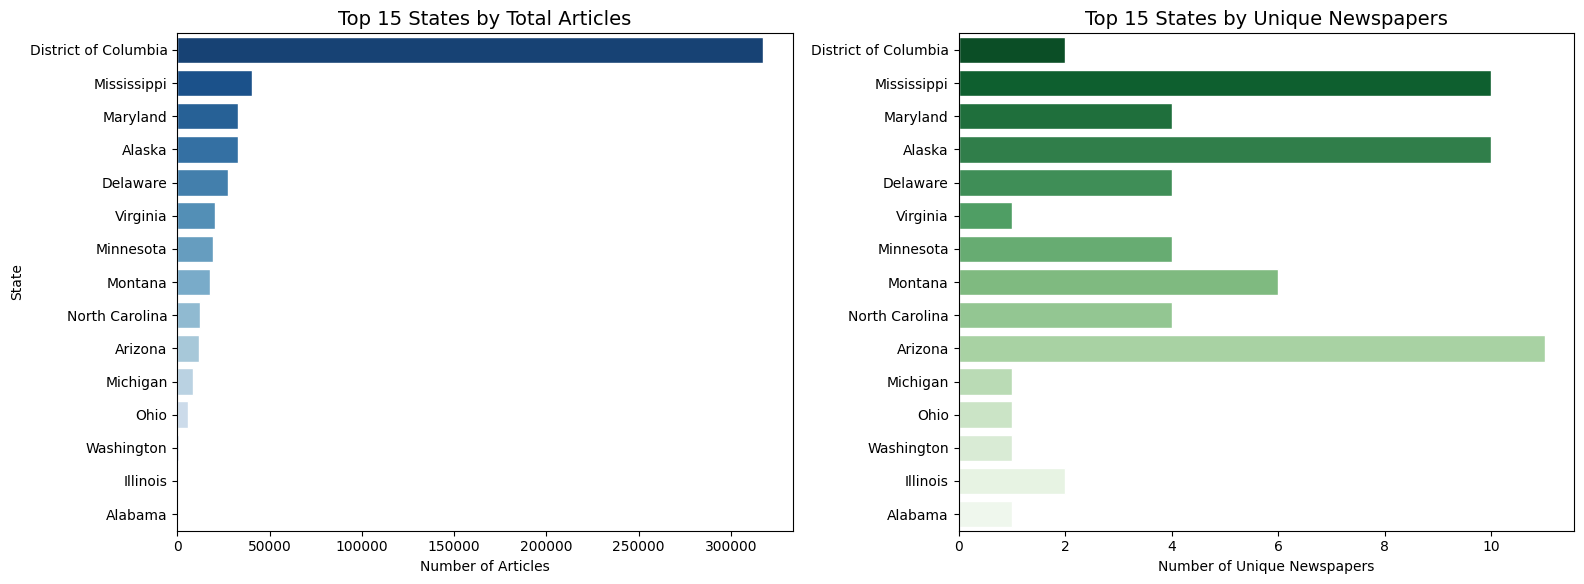

Generating County Visualizations...


/tmp/ipykernel_347/3277370152.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_347/3277370152.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


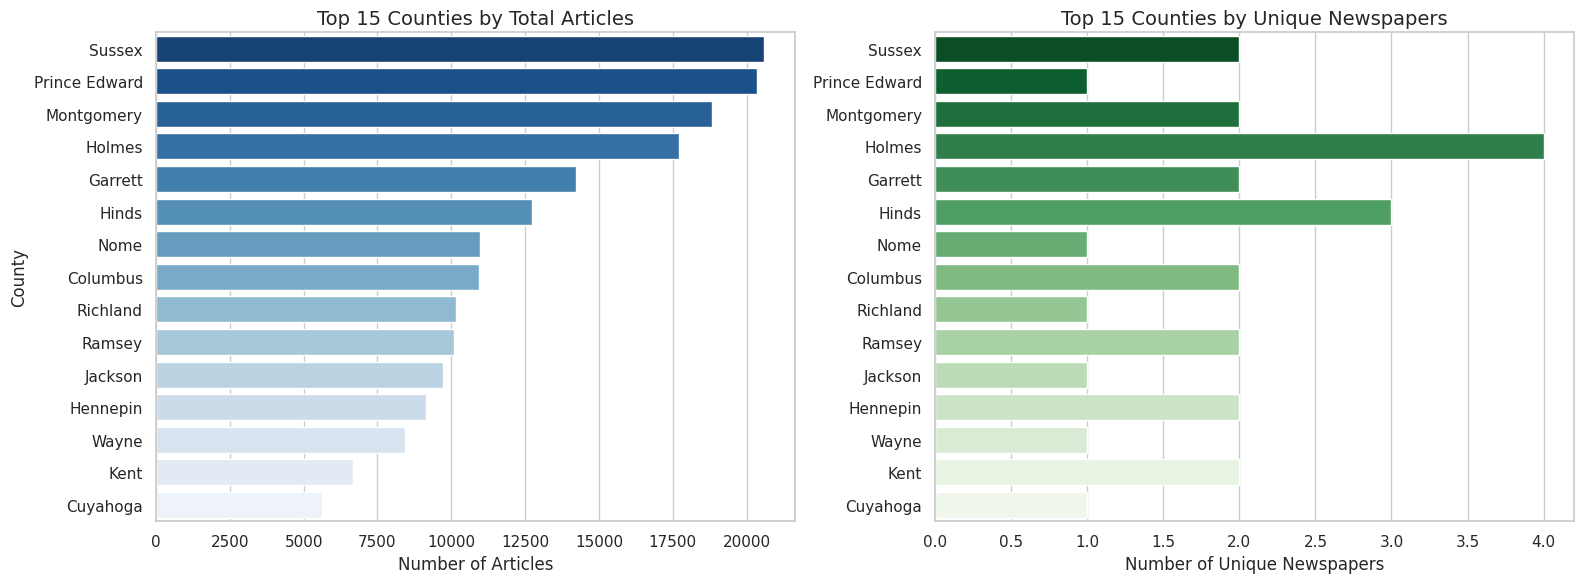

Data processing and visualization complete! CSVs and PNGs have been saved.


In [ ]:



import gdown
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 2. Download and Load Data
# ---------------------------------------------------------
file_id = "17lL06dXXGV_-AuEui8c6WI4WMExQVwt2"
url = f"https://drive.google.com/uc?id={file_id}"
gdown.download(url, "data.csv", quiet=False)

df = pd.read_csv("data.csv")

# ---------------------------------------------------------
# 3. Calculate Summaries
# ---------------------------------------------------------
# State Summary
state_summary = df.groupby('State').agg(
    total_articles=('newspaper_name', 'size'),
    unique_newspapers=('newspaper_name', 'nunique')
).reset_index().sort_values(by='total_articles', ascending=False)

# County Summary (dropping NaNs so blank counties don't skew the chart)
county_summary = df.dropna(subset=['County']).groupby('County').agg(
    total_articles=('newspaper_name', 'size'),
    unique_newspapers=('newspaper_name', 'nunique')
).reset_index().sort_values(by='total_articles', ascending=False)

# Save summaries to CSV
state_summary.to_csv("state_summary.csv", index=False)
county_summary.to_csv("county_summary.csv", index=False)

# ---------------------------------------------------------
# 4. Visualization Function
# ---------------------------------------------------------
def plot_summary(data, location_col, title_prefix, filename):
    # Take the top 15 to keep the charts readable
    top_data = data.head(15)

    # Create a figure with 2 side-by-side subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.set_theme(style="whitegrid")

    # Plot 1: Total Articles
    sns.barplot(
        data=top_data,
        x='total_articles',
        y=location_col,
        ax=axes[0],
        palette='Blues_r'
    )
    axes[0].set_title(f"Top 15 {title_prefix} by Total Articles", fontsize=14)
    axes[0].set_xlabel("Number of Articles")
    axes[0].set_ylabel(location_col)

    # Plot 2: Unique Newspapers
    sns.barplot(
        data=top_data,
        x='unique_newspapers',
        y=location_col,
        ax=axes[1],
        palette='Greens_r'
    )
    axes[1].set_title(f"Top 15 {title_prefix} by Unique Newspapers", fontsize=14)
    axes[1].set_xlabel("Number of Unique Newspapers")
    axes[1].set_ylabel("")

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

# ---------------------------------------------------------
# 5. Generate and Display Visualizations
# ---------------------------------------------------------
print("Generating State Visualizations...")
plot_summary(state_summary, 'State', 'States', 'state_summary_charts.png')

print("Generating County Visualizations...")
plot_summary(county_summary, 'County', 'Counties', 'county_summary_charts.png')

print("Data processing and visualization complete! CSVs and PNGs have been saved.")

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

state_summary = df.groupby('State').agg(
    total_articles=('newspaper_name', 'size'),
    unique_newspapers=('newspaper_name', 'nunique')
).reset_index().sort_values(by='total_articles', ascending=True)

# County Summary (Dropping NaNs and sorting)
county_summary = df.dropna(subset=['County']).groupby('County').agg(
    total_articles=('newspaper_name', 'size'),
    unique_newspapers=('newspaper_name', 'nunique')
).reset_index().sort_values(by='total_articles', ascending=True)

# Save the full comprehensive data to CSVs
state_summary.to_csv("all_states_summary.csv", index=False)
county_summary.to_csv("all_counties_summary.csv", index=False)

# ---------------------------------------------------------
# 4. Interactive State Visualization
# ---------------------------------------------------------
fig_state = make_subplots(rows=1, cols=2, subplot_titles=("Total Articles by State", "Unique Newspapers by State"))

# Add Total Articles
fig_state.add_trace(
    go.Bar(y=state_summary['State'], x=state_summary['total_articles'], orientation='h',
           text=state_summary['total_articles'], textposition='outside', marker_color='#1f77b4'),
    row=1, col=1
)

# Add Unique Newspapers
fig_state.add_trace(
    go.Bar(y=state_summary['State'], x=state_summary['unique_newspapers'], orientation='h',
           text=state_summary['unique_newspapers'], textposition='outside', marker_color='#2ca02c'),
    row=1, col=2
)

# Make the figure tall enough to fit all ~50 states clearly
fig_state.update_layout(height=1200, title_text="Complete State Summary", showlegend=False)
fig_state.show()

# ---------------------------------------------------------
# 5. Interactive County Visualization
# ---------------------------------------------------------
num_counties = len(county_summary)
fig_county = make_subplots(rows=1, cols=2, subplot_titles=("Total Articles by County", "Unique Newspapers by County"))

# Add Total Articles
fig_county.add_trace(
    go.Bar(y=county_summary['County'], x=county_summary['total_articles'], orientation='h',
           text=county_summary['total_articles'], textposition='outside', marker_color='#1f77b4'),
    row=1, col=1
)

# Add Unique Newspapers
fig_county.add_trace(
    go.Bar(y=county_summary['County'], x=county_summary['unique_newspapers'], orientation='h',
           text=county_summary['unique_newspapers'], textposition='outside', marker_color='#2ca02c'),
    row=1, col=2
)

fig_county.update_layout(height=max(800, num_counties * 22),
                         title_text="Complete County Summary (Scrollable)",
                         showlegend=False)
fig_county.show()

In [ ]:
# ---------------------------------------------------------
# 1. Install and Import Libraries
# ---------------------------------------------------------
!pip install -q gdown plotly

import gdown
import pandas as pd
import re
import math
import plotly.express as px

df = pd.read_csv("data.csv")

# Ensure date is properly formatted and extract the Month (YYYY-MM)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['month'] = df['date'].dt.to_period('M').astype(str)

# Ensure article text is string (filling blanks with empty strings)
df['article'] = df['article'].astype(str).fillna('')

# ---------------------------------------------------------
# 3. Define the Keyword Dictionary
# ---------------------------------------------------------
keyword_groups = {
    'Black': ['black', 'african', 'africans', 'blacks', 'colored', 'coloreds', 'negro', 'negros', 'n*er', 'n*ers', 'ni*a', 'ni*as', 'afro', 'afros'],
    'White': ['white', 'whites', 'european', 'europeans', 'british', 'english', 'american', 'americans', 'caucasian', 'caucasians', 'englishman', 'englishmen', 'englishwoman', 'englishwomen'],
    'Rich': ['rich', 'affluent', 'wealthy', 'moneyed', 'wealth', 'aristocrat', 'aristocrats', 'aristocracy', 'prosperous', 'privileged', 'bourgeoisie', 'bourgeois', 'noble', 'nobles', 'nobility', 'nobleman', 'noblemen', 'elite', 'elites', 'benefactor', 'benefactors', 'philanthropist', 'philanthropists', 'millionaire', 'millionaires'],
    'Poor': ['poor', 'beggar', 'beggars', 'needy', 'wretch', 'wretches', 'impoverished', 'destitute', 'penniless', 'unaffluent', 'underprivileged'],
    'Men': ['men', 'man', 'male', 'males', 'he', 'him', 'his', 'himself', 'mr', 'mister', 'boy', 'boys', 'guy', 'guys', 'fella', 'fellas', 'gent', 'gents', 'sir', 'sirs', 'bloke', 'blokes', 'gentleman', 'gentlemen', 'lad', 'lads', 'prince', 'princes', 'king', 'kings'],
    'Women': ['women', 'woman', 'female', 'females', 'she', 'her', 'hers', 'herself', 'mrs', 'ms', 'girl', 'girls', 'gal', 'gals', 'lady', 'ladies', 'dame', 'dames', 'miss', 'missus', 'bride', 'brides', 'maiden', 'maidens', 'gentlewoman', 'gentlewomen', 'lass', 'lassie', 'madam', 'princess', 'princesses', 'queen', 'queens'],
    'Positive': ['good', 'excellent', 'pleasant', 'wonderful', 'honest', 'kind', 'friendly', 'virtuous', 'decent', 'noble', 'cheerful', 'trustworthy'],
    'Negative': ['bad', 'horrible', 'unpleasant', 'horrid', 'dishonest', 'cruel', 'hostile', 'vicious', 'mean', 'nasty', 'vile', 'cowardly']
}

# ---------------------------------------------------------
# 4. Count Keywords in Articles
# ---------------------------------------------------------
print("Scanning articles for keywords (this may take a minute)...")

for category, words in keyword_groups.items():
    # Escape special characters (like *) so regex reads them literally
    escaped_words = [re.escape(w.strip()) for w in words]

    # Create a safe Regex pattern ensuring we only match whole words
    pattern = r"(?i)(?<![A-Za-z])(?:" + "|".join(escaped_words) + r")(?![A-Za-z])"

    # Count the total occurrences of any word in this category for each article
    df[category] = df['article'].str.count(pattern)

# ---------------------------------------------------------
# 5. Group Data for ALL States and ALL Counties
# ---------------------------------------------------------
print("Aggregating data by location and month...")

# Clean data (drop missing states/counties/months)
clean_df_state = df.dropna(subset=['State', 'month'])
clean_df_county = df.dropna(subset=['County', 'month'])

# Aggregate ALL States
state_month_freq = clean_df_state.groupby(['State', 'month'])[list(keyword_groups.keys())].sum().reset_index()
state_month_freq = state_month_freq.sort_values(['State', 'month'])
state_month_freq.to_csv("keyword_frequency_by_ALL_states_month.csv", index=False)

# Aggregate ALL Counties
county_month_freq = clean_df_county.groupby(['County', 'month'])[list(keyword_groups.keys())].sum().reset_index()
county_month_freq = county_month_freq.sort_values(['County', 'month'])
county_month_freq.to_csv("keyword_frequency_by_ALL_counties_month.csv", index=False)

print("Saved exact counts to CSV files! Generating charts...")

# ---------------------------------------------------------
# 6. Interactive Visualizations for ALL Locations
# ---------------------------------------------------------
cols_per_row = 3 # Display 3 charts per row

# --- PLOT 1: ALL STATES ---
num_states = state_month_freq['State'].nunique()
state_rows = math.ceil(num_states / cols_per_row)

fig_state = px.line(
    state_month_freq,
    x='month',
    y=['Black', 'White'], # Change these categories if you want to plot Men vs Women, etc.
    facet_col='State',
    facet_col_wrap=cols_per_row,
    title="Keyword Frequency (Black vs. White) in ALL States",
    labels={'value': 'Mentions', 'variable': 'Category', 'month': 'Month'},
    height=state_rows * 250 # Dynamically scales height so charts never squish
)
fig_state.update_layout(hovermode="x unified")
fig_state.update_xaxes(tickangle=45)
fig_state.show()

# --- PLOT 2: ALL COUNTIES ---
num_counties = county_month_freq['County'].nunique()
county_rows = math.ceil(num_counties / cols_per_row)

fig_county = px.line(
    county_month_freq,
    x='month',
    y=['Black', 'White'],
    facet_col='County',
    facet_col_wrap=cols_per_row,
    title="Keyword Frequency (Black vs. White) in ALL Counties",
    labels={'value': 'Mentions', 'variable': 'Category', 'month': 'Month'},
    height=county_rows * 250
)
fig_county.update_layout(hovermode="x unified")
fig_county.update_xaxes(tickangle=45)
fig_county.show()

print("All processing and plotting complete!")

Scanning articles for keywords (this may take a minute)...
Aggregating data by location and month...
Saved exact counts to CSV files! Generating charts...


All processing and plotting complete!


In [ ]:
import math
import plotly.express as px

def plot_comparison(df, location_column, category_pair):

    location_type = "States" if location_column == "State" else "Counties"


    num_locations = df[location_column].nunique()
    cols_per_row = 3
    rows = math.ceil(num_locations / cols_per_row)

    # Draw the chart
    fig = px.line(
        df,
        x='month',
        y=category_pair,
        facet_col=location_column,
        facet_col_wrap=cols_per_row,
        title=f"Keyword Frequency ({category_pair[0]} vs. {category_pair[1]}) in ALL {location_type}",
        labels={'value': 'Mentions', 'variable': 'Category', 'month': 'Month'},
        height=rows * 250
    )
    fig.update_layout(hovermode="x unified")
    fig.update_xaxes(tickangle=45)
    fig.show()

In [ ]:
# Plot for States
plot_comparison(state_month_freq, 'State', ['Rich', 'Poor'])

# Plot for Counties
plot_comparison(county_month_freq, 'County', ['Rich', 'Poor'])

In [ ]:
# Plot for States
plot_comparison(state_month_freq, 'State', ['Men', 'Women'])

# Plot for Counties
plot_comparison(county_month_freq, 'County', ['Men', 'Women'])

In [ ]:
# Plot for States
plot_comparison(state_month_freq, 'State', ['Positive', 'Negative'])

# Plot for Counties
plot_comparison(county_month_freq, 'County', ['Positive', 'Negative'])

# Phase 3 The Embedding

In [ ]:
!pip install -q gdown gensim plotly tqdm

In [ ]:

import gdown
import pandas as pd

file_id = "17lL06dXXGV_-AuEui8c6WI4WMExQVwt2"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "data.csv", quiet=False)

df = pd.read_csv("data.csv")
df.head()

Downloading...
From (original): https://drive.google.com/uc?id=17lL06dXXGV_-AuEui8c6WI4WMExQVwt2
From (redirected): https://drive.google.com/uc?id=17lL06dXXGV_-AuEui8c6WI4WMExQVwt2&confirm=t&uuid=354c6b8e-8b28-4a67-8ed3-966163ba1fec
To: /content/data.csv
100%|██████████| 497M/497M [00:04<00:00, 120MB/s]


,article_id,date,newspaper_name,headline,article,LCCN,State,County,City
0,3_1963-12-15_p23_sn83045462_00280609249_196312...,1963-12-15,"Evening star. [volume] (Washington, D.C.) 1854...",Air Pollution,Both House and Senate last\nweek also cleared ...,sn83045462,District of Columbia,NaN,Washington
1,4_1963-12-15_p23_sn83045462_00280609249_196312...,1963-12-15,"Evening star. [volume] (Washington, D.C.) 1854...",THE WEEK IN PERSPECTIVE\nOn Spending and Politics,President Johnson drove ahead\non his economy ...,sn83045462,District of Columbia,NaN,Washington
2,5_1963-12-15_p23_sn83045462_00280609249_196312...,1963-12-15,"Evening star. [volume] (Washington, D.C.) 1854...",Succession::\nNew SYSTEM?,"The fact that House Speaker\nMccormack, ~, and...",sn83045462,District of Columbia,NaN,Washington
3,6_1963-12-15_p23_sn83045462_00280609249_196312...,1963-12-15,"Evening star. [volume] (Washington, D.C.) 1854...",Congress-:\n\n\nAid Watchdog,The foreign-aid program suf-\n\n\nfered the de...,sn83045462,District of Columbia,NaN,Washington
4,7_1963-12-15_p23_sn83045462_00280609249_196312...,1963-12-15,"Evening star. [volume] (Washington, D.C.) 1854...",More Incentive,Many Americans would say that\nincentive rathe...,sn83045462,District of Columbia,NaN,Washington


In [ ]:
import logging
# This turns on Gensim's internal logging so you can see it processing batches
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

# Alert RAM Crash

In [ ]:
# ---------------------------------------------------------
# 1. Install Libraries & Setup
# ---------------------------------------------------------

import re
import os
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from gensim.models import FastText
from sklearn.decomposition import PCA
import plotly.express as px
import logging

logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

# ---------------------------------------------------------
# 2. Text Processing & Tokenization Helpers
# ---------------------------------------------------------
TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")

def ft_tokenize(text):
    return TOKEN_RE.findall(str(text).lower())

def split_into_sentences(text):
    return [s.strip() for s in re.split(r"[.!?\n]+", str(text)) if s.strip()]

keyword_groups = {
    'Black': ['black', 'african', 'africans', 'blacks', 'colored', 'coloreds', 'negro', 'negros', 'n*er', 'n*ers', 'ni*a', 'ni*as', 'afro', 'afros'],
    'White': ['white', 'whites', 'european', 'europeans', 'british', 'english', 'american', 'americans', 'caucasian', 'caucasians', 'englishman', 'englishmen', 'englishwoman', 'englishwomen'],
    'Rich': ['rich', 'affluent', 'wealthy', 'moneyed', 'wealth', 'aristocrat', 'aristocrats', 'aristocracy', 'prosperous', 'privileged', 'bourgeoisie', 'bourgeois', 'noble', 'nobles', 'nobility', 'nobleman', 'noblemen', 'elite', 'elites', 'benefactor', 'benefactors', 'philanthropist', 'philanthropists', 'millionaire', 'millionaires'],
    'Poor': ['poor', 'beggar', 'beggars', 'needy', 'wretch', 'wretches', 'impoverished', 'destitute', 'penniless', 'unaffluent', 'underprivileged'],
    'Men': ['men', 'man', 'male', 'males', 'he', 'him', 'his', 'himself', 'mr', 'mister', 'boy', 'boys', 'guy', 'guys', 'fella', 'fellas', 'gent', 'gents', 'sir', 'sirs', 'bloke', 'blokes', 'gentleman', 'gentlemen', 'lad', 'lads', 'prince', 'princes', 'king', 'kings'],
    'Women': ['women', 'woman', 'female', 'females', 'she', 'her', 'hers', 'herself', 'mrs', 'ms', 'girl', 'girls', 'gal', 'gals', 'lady', 'ladies', 'dame', 'dames', 'miss', 'missus', 'bride', 'brides', 'maiden', 'maidens', 'gentlewoman', 'gentlewomen', 'lass', 'lassie', 'madam', 'princess', 'princesses', 'queen', 'queens'],
    'Positive': ['good', 'excellent', 'pleasant', 'wonderful', 'honest', 'kind', 'friendly', 'virtuous', 'decent', 'noble', 'cheerful', 'trustworthy'],
    'Negative': ['bad', 'horrible', 'unpleasant', 'horrid', 'dishonest', 'cruel', 'hostile', 'vicious', 'mean', 'nasty', 'vile', 'cowardly']
}

keyword_groups_ft = {
    category: sorted({w.lower() for w in words if re.fullmatch(r"[A-Za-z]+", w)})
    for category, words in keyword_groups.items()
}

# ---------------------------------------------------------
# 3. Streamed FastText Training (RAM Saver)
# ---------------------------------------------------------
class SentenceStreamer:
    def __init__(self, text_series):
        self.text_series = text_series

    def __iter__(self):
        # Wrap the iteration with tqdm to show a progress bar
        for text in tqdm(self.text_series, desc="FastText Processing (Vocab/Epoch)"):
            if not isinstance(text, str) or not text.strip():
                continue
            for sent in split_into_sentences(text):
                tokens = ft_tokenize(sent)
                if len(tokens) >= 5:
                    yield tokens

print("Streaming data to FastText (this prevents RAM crashes)...")
cores = os.cpu_count()
sentences_iterator = SentenceStreamer(df['article'])

# Note: FastText will iterate through your data multiple times!
# Pass 1: Building the Vocabulary
# Passes 2-6: Training the epochs (default is 5 epochs)
ft_model = FastText(
    sentences=sentences_iterator,
    vector_size=100,
    window=5,
    min_count=5,
    workers=cores,
    sg=1
)
print("FastText training complete!")

# ---------------------------------------------------------
# 4. Memory-Efficient Context Extraction
# ---------------------------------------------------------
def extract_contexts_from_series(text_series, terms, window_size=5, min_context_tokens=2):
    """Extracts contexts by tokenizing on the fly, saving massive amounts of RAM."""
    term_set = set(terms)
    contexts = []

    for text in text_series:
        if not isinstance(text, str) or not text.strip():
            continue
        for sent in split_into_sentences(text):
            tokens = ft_tokenize(sent)
            for i, tok in enumerate(tokens):
                if tok in term_set:
                    left = tokens[max(0, i - window_size):i]
                    right = tokens[i + 1:i + 1 + window_size]
                    context = left + right
                    if len(context) >= min_context_tokens:
                        contexts.append(context)
    return contexts

def get_mean_context_vector(contexts, model):
    words = [word for context in contexts for word in context if word in model.wv]
    if not words:
        return None
    vecs = [model.wv[w] for w in words]
    mean_vec = np.mean(vecs, axis=0)
    return mean_vec / (np.linalg.norm(mean_vec) + 1e-12)

def cosine_sim(a, b):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-12
    return float(np.dot(a, b) / denom)

# ---------------------------------------------------------
# 5. Build Global and Local Vectors
# ---------------------------------------------------------
def build_global_category_vectors(df_data, keyword_groups_ft, model, min_contexts=20, window_size=5):
    global_vectors = {}
    rows = []

    for category, terms in keyword_groups_ft.items():
        # Pass the raw text series directly
        contexts = extract_contexts_from_series(df_data["article"], terms, window_size=window_size)
        if len(contexts) < min_contexts:
            continue

        vec = get_mean_context_vector(contexts, model)
        if vec is not None:
            global_vectors[category] = vec
            rows.append({"category": category, "n_contexts": len(contexts)})

    return global_vectors, pd.DataFrame(rows)

def build_location_category_embeddings(df_data, location_col, keyword_groups_ft, model, top_n=None, min_contexts=15, window_size=5):
    work = df_data[[location_col, "article"]].dropna(subset=[location_col]).copy()

    if top_n is not None:
        top_locations = work[location_col].value_counts().head(top_n).index
        work = work[work[location_col].isin(top_locations)]

    embeddings = {}
    rows = []

    grouped = work.groupby(location_col)
    for location, group in tqdm(grouped, total=work[location_col].nunique(), desc=f"Processing {location_col}"):

        for category, terms in keyword_groups_ft.items():
            # Extract contexts on the fly for this specific location group
            contexts = extract_contexts_from_series(group["article"], terms, window_size=window_size)
            if len(contexts) < min_contexts:
                continue

            vec = get_mean_context_vector(contexts, model)
            if vec is not None:
                embeddings[(location, category)] = vec
                rows.append({
                    location_col: location,
                    "category": category,
                    "n_contexts": len(contexts)
                })

    return embeddings, pd.DataFrame(rows)

def build_similarity_table(location_embeddings, global_vectors, location_col):
    rows = []
    for (location, category), vec in location_embeddings.items():
        if category in global_vectors:
            rows.append({
                location_col: location,
                "category": category,
                "cosine_to_global": cosine_sim(vec, global_vectors[category])
            })
    return pd.DataFrame(rows)

# ---------------------------------------------------------
# 6. Execute Analysis (ON FULL DATA)
# ---------------------------------------------------------
print("Building Global Average Vectors...")
global_vectors, global_meta = build_global_category_vectors(df, keyword_groups_ft, ft_model, min_contexts=20)

print("Building State Vectors...")
state_embeddings, state_meta = build_location_category_embeddings(
    df, location_col="State", keyword_groups_ft=keyword_groups_ft, model=ft_model, top_n=None, min_contexts=15
)

print("Building County Vectors...")
county_embeddings, county_meta = build_location_category_embeddings(
    df, location_col="County", keyword_groups_ft=keyword_groups_ft, model=ft_model, top_n=30, min_contexts=15
)

state_scores = build_similarity_table(state_embeddings, global_vectors, "State")
county_scores = build_similarity_table(county_embeddings, global_vectors, "County")

state_scores.to_csv("state_fasttext_keyword_similarity.csv", index=False)
county_scores.to_csv("county_fasttext_keyword_similarity.csv", index=False)
print("Analysis complete and saved to CSV!")

# ---------------------------------------------------------
# 7. Visualizations
# ---------------------------------------------------------
def plot_similarity_heatmap(score_df, location_col, title):
    if score_df.empty:
        print(f"Not enough data to plot {location_col}.")
        return

    pivot = score_df.pivot(index=location_col, columns="category", values="cosine_to_global")

    fig = px.imshow(
        pivot,
        aspect="auto",
        color_continuous_scale="RdBu",
        zmin=-1,
        zmax=1,
        title=title
    )
    fig.update_layout(height=max(500, 25 * len(pivot)), xaxis_title="Category", yaxis_title=location_col)
    fig.show()

def plot_embedding_scatter(location_embeddings, location_col, title):
    rows = []
    vectors = []

    for (location, category), vec in location_embeddings.items():
        rows.append({location_col: location, "category": category})
        vectors.append(vec)

    if len(vectors) < 2:
        return

    vectors = np.vstack(vectors)
    coords = PCA(n_components=2).fit_transform(vectors)

    plot_df = pd.DataFrame(rows)
    plot_df["pc1"] = coords[:, 0]
    plot_df["pc2"] = coords[:, 1]

    fig = px.scatter(
        plot_df, x="pc1", y="pc2", color="category", hover_name=location_col, title=title
    )
    fig.update_traces(marker=dict(size=8, opacity=0.7))
    fig.show()

plot_similarity_heatmap(state_scores, "State", "FastText Semantic Similarity by State (vs National Baseline)")
plot_similarity_heatmap(county_scores, "County", "FastText Semantic Similarity by County (vs National Baseline)")

plot_embedding_scatter(state_embeddings, "State", "2D Semantic Map: How States talk about Categories")
plot_embedding_scatter(county_embeddings, "County", "2D Semantic Map: How Counties talk about Categories")

Streaming data to FastText (this prevents RAM crashes)...


FastText Processing (Vocab/Epoch):   0%|          | 0/547783 [00:00<?, ?it/s]

FastText Processing (Vocab/Epoch):   0%|          | 0/547783 [00:00<?, ?it/s]

FastText Processing (Vocab/Epoch):   0%|          | 0/547783 [00:00<?, ?it/s]

FastText Processing (Vocab/Epoch):   0%|          | 0/547783 [00:00<?, ?it/s]

...

FastText training complete!
Building Global Average Vectors...
Building State Vectors...


Processing State:   0%|          | 0/15 [00:00<?, ?it/s]

Building County Vectors...


Processing County:   0%|          | 0/30 [00:00<?, ?it/s]

Analysis complete and saved to CSV!


In [ ]:

plot_similarity_heatmap(state_scores, "State", "FastText Semantic Similarity by State (Test)")
plot_similarity_heatmap(county_scores, "County", "FastText Semantic Similarity by County (Test)")

plot_embedding_scatter(state_embeddings, "State", "2D Semantic Map: States (Test)")
plot_embedding_scatter(county_embeddings, "County", "2D Semantic Map: Counties (Test)")

In [ ]:
plot_similarity_heatmap(state_scores, "State", "FastText Semantic Similarity by State (vs National Baseline)")
plot_similarity_heatmap(county_scores, "County", "FastText Semantic Similarity by County (vs National Baseline)")

# Bert based Token level embedding

In [ ]:
!pip install -q gdown  plotly tqdm

In [ ]:

import gdown
import pandas as pd

file_id = "17lL06dXXGV_-AuEui8c6WI4WMExQVwt2"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "data.csv", quiet=False)

df = pd.read_csv("data.csv")
df.head()

Downloading...
From (original): https://drive.google.com/uc?id=17lL06dXXGV_-AuEui8c6WI4WMExQVwt2
From (redirected): https://drive.google.com/uc?id=17lL06dXXGV_-AuEui8c6WI4WMExQVwt2&confirm=t&uuid=ac547f18-98bc-4df3-a98b-9a1178669668
To: /content/data.csv
100%|██████████| 497M/497M [00:04<00:00, 115MB/s] 


,article_id,date,newspaper_name,headline,article,LCCN,State,County,City
0,3_1963-12-15_p23_sn83045462_00280609249_196312...,1963-12-15,"Evening star. [volume] (Washington, D.C.) 1854...",Air Pollution,Both House and Senate last\nweek also cleared ...,sn83045462,District of Columbia,NaN,Washington
1,4_1963-12-15_p23_sn83045462_00280609249_196312...,1963-12-15,"Evening star. [volume] (Washington, D.C.) 1854...",THE WEEK IN PERSPECTIVE\nOn Spending and Politics,President Johnson drove ahead\non his economy ...,sn83045462,District of Columbia,NaN,Washington
2,5_1963-12-15_p23_sn83045462_00280609249_196312...,1963-12-15,"Evening star. [volume] (Washington, D.C.) 1854...",Succession::\nNew SYSTEM?,"The fact that House Speaker\nMccormack, ~, and...",sn83045462,District of Columbia,NaN,Washington
3,6_1963-12-15_p23_sn83045462_00280609249_196312...,1963-12-15,"Evening star. [volume] (Washington, D.C.) 1854...",Congress-:\n\n\nAid Watchdog,The foreign-aid program suf-\n\n\nfered the de...,sn83045462,District of Columbia,NaN,Washington
4,7_1963-12-15_p23_sn83045462_00280609249_196312...,1963-12-15,"Evening star. [volume] (Washington, D.C.) 1854...",More Incentive,Many Americans would say that\nincentive rathe...,sn83045462,District of Columbia,NaN,Washington


In [ ]:
import re
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer


# ---------------------------------------------------------
# 0. Optional dependencies
# ---------------------------------------------------------
try:
    from pandarallel import pandarallel
except ImportError:
    pandarallel = None


# ---------------------------------------------------------
# 1. Setup
# ---------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "microsoft/MiniLM-L12-H384-uncased"

BATCH_SIZE = 64                  # Changed from 256
MAX_LENGTH = 256
CHUNK_WORDS = 220
CHUNK_OVERLAP = 40
WINDOW_SIZE = 5
MIN_CONTEXTS_GLOBAL = 20
MIN_CONTEXTS_LOCAL = 15
NUM_DATALOADER_WORKERS = 0       # Changed from 4
NUM_CPU_WORKERS = 0              # Changed from 2 (no longer used)
MAX_PENDING_CPU_BATCHES = 0      # (no longer used)
USE_PANDARALLEL = False

print("Using device:", DEVICE)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()


# ---------------------------------------------------------
# 2. Text processing
# ---------------------------------------------------------
TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")


def basic_tokenize(text):
    return TOKEN_RE.findall(str(text).lower())


keyword_groups = {
    "Black": ["black", "african", "africans", "blacks", "colored", "coloreds", "negro", "negros", "afro", "afros"],
    "White": ["white", "whites", "european", "europeans", "british", "english", "american", "americans", "caucasian", "caucasians", "englishman", "englishmen", "englishwoman", "englishwomen"],
    "Rich": ["rich", "affluent", "wealthy", "moneyed", "wealth", "aristocrat", "aristocrats", "aristocracy", "prosperous", "privileged", "bourgeoisie", "bourgeois", "noble", "nobles", "nobility", "nobleman", "noblemen", "elite", "elites", "benefactor", "benefactors", "philanthropist", "philanthropists", "millionaire", "millionaires"],
    "Poor": ["poor", "beggar", "beggars", "needy", "wretch", "wretches", "impoverished", "destitute", "penniless", "unaffluent", "underprivileged"],
    "Men": ["men", "man", "male", "males", "he", "him", "his", "himself", "mr", "mister", "boy", "boys", "guy", "guys", "fella", "fellas", "gent", "gents", "sir", "sirs", "bloke", "blokes", "gentleman", "gentlemen", "lad", "lads", "prince", "princes", "king", "kings"],
    "Women": ["women", "woman", "female", "females", "she", "her", "hers", "herself", "mrs", "ms", "girl", "girls", "gal", "gals", "lady", "ladies", "dame", "dames", "miss", "missus", "bride", "brides", "maiden", "maidens", "gentlewoman", "gentlewomen", "lass", "lassie", "madam", "princess", "princesses", "queen", "queens"],
    "Positive": ["good", "excellent", "pleasant", "wonderful", "honest", "kind", "friendly", "virtuous", "decent", "noble", "cheerful", "trustworthy"],
    "Negative": ["bad", "horrible", "unpleasant", "horrid", "dishonest", "cruel", "hostile", "vicious", "mean", "nasty", "vile", "cowardly"],
}

keyword_groups_clean = {
    category: sorted({w.lower() for w in words if re.fullmatch(r"[A-Za-z]+", w)})
    for category, words in keyword_groups.items()
}

term_to_categories = defaultdict(list)
all_terms = set()
for category, terms in keyword_groups_clean.items():
    for term in terms:
        term_to_categories[term].append(category)
        all_terms.add(term)


# ---------------------------------------------------------
# 3. Chunking and filtering
# ---------------------------------------------------------
def chunk_words(words, max_words=220, overlap=40):
    if len(words) <= max_words:
        return [words]

    chunks = []
    step = max_words - overlap
    for start in range(0, len(words), step):
        chunk = words[start:start + max_words]
        if chunk:
            chunks.append(chunk)
        if start + max_words >= len(words):
            break
    return chunks


def build_compiled_regex():
    regex_pattern = r"\b(" + "|".join(map(re.escape, sorted(all_terms, key=len, reverse=True))) + r")\b"
    return re.compile(regex_pattern, re.IGNORECASE)


def filter_relevant_articles(df_data, text_col="article", use_pandarallel=USE_PANDARALLEL):
    compiled_regex = build_compiled_regex()
    series = df_data[text_col].fillna("")

    if use_pandarallel and pandarallel is not None:
        pandarallel.initialize(progress_bar=True, nb_workers=NUM_DATALOADER_WORKERS)
        mask = series.parallel_map(lambda x: bool(compiled_regex.search(str(x))))
    else:
        mask = series.map(lambda x: bool(compiled_regex.search(str(x))))

    return df_data.loc[mask].copy()


class ChunkedArticleDataset(Dataset):
    def __init__(self, df_data, text_col="article", state_col="State", county_col="County"):
        records = []

        for row in df_data[[text_col, state_col, county_col]].itertuples(index=False):
            text = row[0]
            state = row[1]
            county = row[2]

            if not isinstance(text, str) or not text.strip():
                continue

            words = basic_tokenize(text)
            if not words:
                continue

            for chunk in chunk_words(words, max_words=CHUNK_WORDS, overlap=CHUNK_OVERLAP):
                records.append({
                    "words": chunk,
                    "state": state,
                    "county": county,
                })

        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        return self.records[idx]


def collate_chunk_records(batch):
    return batch


# ---------------------------------------------------------
# 4. Fast accumulators
# ---------------------------------------------------------
class VectorAccumulator:
    def __init__(self, dim=384):
        self.sum = np.zeros(dim, dtype=np.float64)
        self.count = 0

    def add(self, vec):
        self.sum += vec.astype(np.float64, copy=False)
        self.count += 1

    def merge(self, vec_sum, count):
        self.sum += vec_sum.astype(np.float64, copy=False)
        self.count += int(count)

    def mean_unit(self):
        if self.count == 0:
            return None
        vec = self.sum / self.count
        norm = np.linalg.norm(vec) + 1e-12
        return (vec / norm).astype(np.float32)


def merge_partial_accumulators(target_acc, partial_acc):
    for key, (vec_sum, count) in partial_acc.items():
        target_acc[key].merge(vec_sum, count)


def build_context_token_positions(encodings, batch_index, word_count, window_size):
    positions_by_word = []
    for word_idx in range(word_count):
        # FIXED: Passing arguments positionally instead of using 'batch_index='
        span = encodings.word_to_tokens(batch_index, word_idx)

        if span is None:
            positions_by_word.append([])
        else:
            positions_by_word.append(list(range(span.start, span.end)))

    context_positions = []
    for word_idx in range(word_count):
        left = max(0, word_idx - window_size)
        right = min(word_count, word_idx + window_size + 1)
        token_positions = []
        for ctx_word_idx in range(left, right):
            if ctx_word_idx != word_idx:
                token_positions.extend(positions_by_word[ctx_word_idx])
        context_positions.append(token_positions)

    return context_positions


def extract_batch_payload(encodings, hidden_cpu, batch_records, window_size):
    payload = []
    for b_idx, record in enumerate(batch_records):
        words = record["words"]
        context_positions = build_context_token_positions(encodings, b_idx, len(words), window_size)
        payload.append({
            "hidden": hidden_cpu[b_idx],
            "words": words,
            "state": record["state"],
            "county": record["county"],
            "context_positions": context_positions,
        })
    return payload


def process_payload_batch(payload):
    global_partial = defaultdict(lambda: [np.zeros(384, dtype=np.float64), 0])
    state_partial = defaultdict(lambda: [np.zeros(384, dtype=np.float64), 0])
    county_partial = defaultdict(lambda: [np.zeros(384, dtype=np.float64), 0])

    for item in payload:
        hidden = item["hidden"]
        words = item["words"]
        state = item["state"]
        county = item["county"]
        context_positions = item["context_positions"]

        for word_idx, word in enumerate(words):
            if word not in term_to_categories:
                continue

            token_positions = context_positions[word_idx]
            if len(token_positions) < 2:
                continue

            vec = hidden[token_positions].mean(axis=0)
            vec /= np.linalg.norm(vec) + 1e-12

            for category in term_to_categories[word]:
                global_partial[category][0] += vec
                global_partial[category][1] += 1

                if pd.notna(state):
                    state_partial[(state, category)][0] += vec
                    state_partial[(state, category)][1] += 1

                if pd.notna(county):
                    county_partial[(county, category)][0] += vec
                    county_partial[(county, category)][1] += 1

    return dict(global_partial), dict(state_partial), dict(county_partial)


def cosine_sim(a, b):
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-12
    return float(np.dot(a, b) / denom)


def finalize_global_vectors(global_acc, min_contexts=20):
    global_vectors = {}
    rows = []

    for category, acc in global_acc.items():
        if acc.count < min_contexts:
            continue
        vec = acc.mean_unit()
        if vec is None:
            continue
        global_vectors[category] = vec
        rows.append({"category": category, "n_contexts": acc.count})

    return global_vectors, pd.DataFrame(rows)


def finalize_location_vectors(location_acc, location_col, min_contexts=15):
    vectors = {}
    rows = []

    for (location, category), acc in location_acc.items():
        if acc.count < min_contexts:
            continue
        vec = acc.mean_unit()
        if vec is None:
            continue
        vectors[(location, category)] = vec
        rows.append({
            location_col: location,
            "category": category,
            "n_contexts": acc.count,
        })

    return vectors, pd.DataFrame(rows)


def build_similarity_table(location_vectors, global_vectors, location_col):
    rows = []
    for (location, category), vec in location_vectors.items():
        if category not in global_vectors:
            continue
        rows.append({
            location_col: location,
            "category": category,
            "cosine_to_global": cosine_sim(vec, global_vectors[category]),
        })
    return pd.DataFrame(rows)


# ---------------------------------------------------------
# 5. Single-pass pipelined inference
# ---------------------------------------------------------
@torch.inference_mode()  # Faster than @torch.no_grad()
def submit_gpu_batch(batch_records, max_length=256, window_size=5):
    batch_words = [record["words"] for record in batch_records]

    enc = tokenizer(
        batch_words,
        is_split_into_words=True,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=max_length,
    )
    enc_gpu = {k: v.to(DEVICE, non_blocking=True) for k, v in enc.items()}

    outputs = model(**enc_gpu)
    # No need for .detach() when using inference_mode()
    hidden_cpu = outputs.last_hidden_state.cpu().numpy().astype(np.float32)
    payload = extract_batch_payload(enc, hidden_cpu, batch_records, window_size=window_size)
    return payload





def run_pipeline(
    df_data,
    text_col="article",
    state_col="State",
    county_col="County",
    top_n_counties=30,
):
    print("Pre-filtering dataset to find relevant articles...")
    df_relevant = filter_relevant_articles(df_data, text_col=text_col)
    print(f"Reduced dataset from {len(df_data)} to {len(df_relevant)} relevant articles.")

    if top_n_counties is not None:
        top_counties = set(df_relevant[county_col].value_counts().head(top_n_counties).index)
        df_relevant = df_relevant[df_relevant[county_col].isna() | df_relevant[county_col].isin(top_counties)].copy()

    dataset = ChunkedArticleDataset(
        df_relevant,
        text_col=text_col,
        state_col=state_col,
        county_col=county_col,
    )

    dataloader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_DATALOADER_WORKERS,  # Now set to 0
        pin_memory=(DEVICE == "cuda"),
        # persistent_workers requires num_workers > 0, so disable it dynamically:
        persistent_workers=False,
        collate_fn=collate_chunk_records,
    )

    global_acc = defaultdict(VectorAccumulator)
    state_acc = defaultdict(VectorAccumulator)
    county_acc = defaultdict(VectorAccumulator)

    # REPLACED MULTIPROCESSING WITH A DIRECT, SYNCHRONOUS LOOP
    for batch_records in tqdm(dataloader, desc="MiniLM chunk batches"):
        # 1. Run GPU Inference
        payload = submit_gpu_batch(
            batch_records,
            max_length=MAX_LENGTH,
            window_size=WINDOW_SIZE,
        )

        # 2. Process the arrays immediately on the CPU in the main thread
        partial_global, partial_state, partial_county = process_payload_batch(payload)

        # 3. Merge results
        merge_partial_accumulators(global_acc, partial_global)
        merge_partial_accumulators(state_acc, partial_state)
        merge_partial_accumulators(county_acc, partial_county)

    # Finalize outputs
    global_vectors, global_meta = finalize_global_vectors(global_acc, min_contexts=MIN_CONTEXTS_GLOBAL)
    state_vectors, state_meta = finalize_location_vectors(state_acc, location_col=state_col, min_contexts=MIN_CONTEXTS_LOCAL)
    county_vectors, county_meta = finalize_location_vectors(county_acc, location_col=county_col, min_contexts=MIN_CONTEXTS_LOCAL)

    state_scores = build_similarity_table(state_vectors, global_vectors, state_col)
    county_scores = build_similarity_table(county_vectors, global_vectors, county_col)

    return {
        "df_relevant": df_relevant,
        "global_vectors": global_vectors,
        "global_meta": global_meta,
        "state_vectors": state_vectors,
        "state_meta": state_meta,
        "county_vectors": county_vectors,
        "county_meta": county_meta,
        "state_scores": state_scores,
        "county_scores": county_scores,
    }


# ---------------------------------------------------------
# 6. Run
# ---------------------------------------------------------
if __name__ == "__main__":
    results = run_pipeline(
        df,
        text_col="article",
        state_col="State",
        county_col="County",
        top_n_counties=30,
    )

    results["state_scores"].to_csv("state_minilm_token_similarity.csv", index=False)
    results["county_scores"].to_csv("county_minilm_token_similarity.csv", index=False)

    print("Done.")


Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Pre-filtering dataset to find relevant articles...
Reduced dataset from 547783 to 348653 relevant articles.


MiniLM chunk batches:   0%|          | 0/7146 [00:00<?, ?it/s]

Done.


Loading data from CSVs...
Plotting State Heatmap...


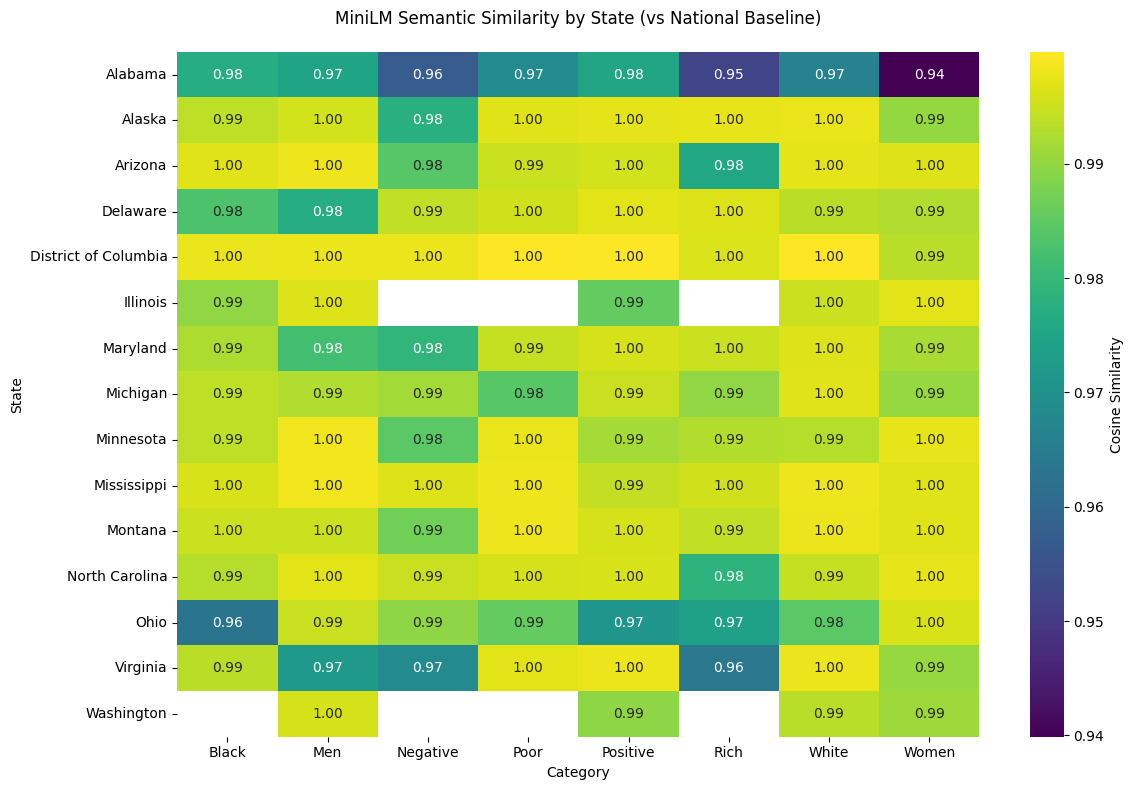

Plotting County Heatmap...


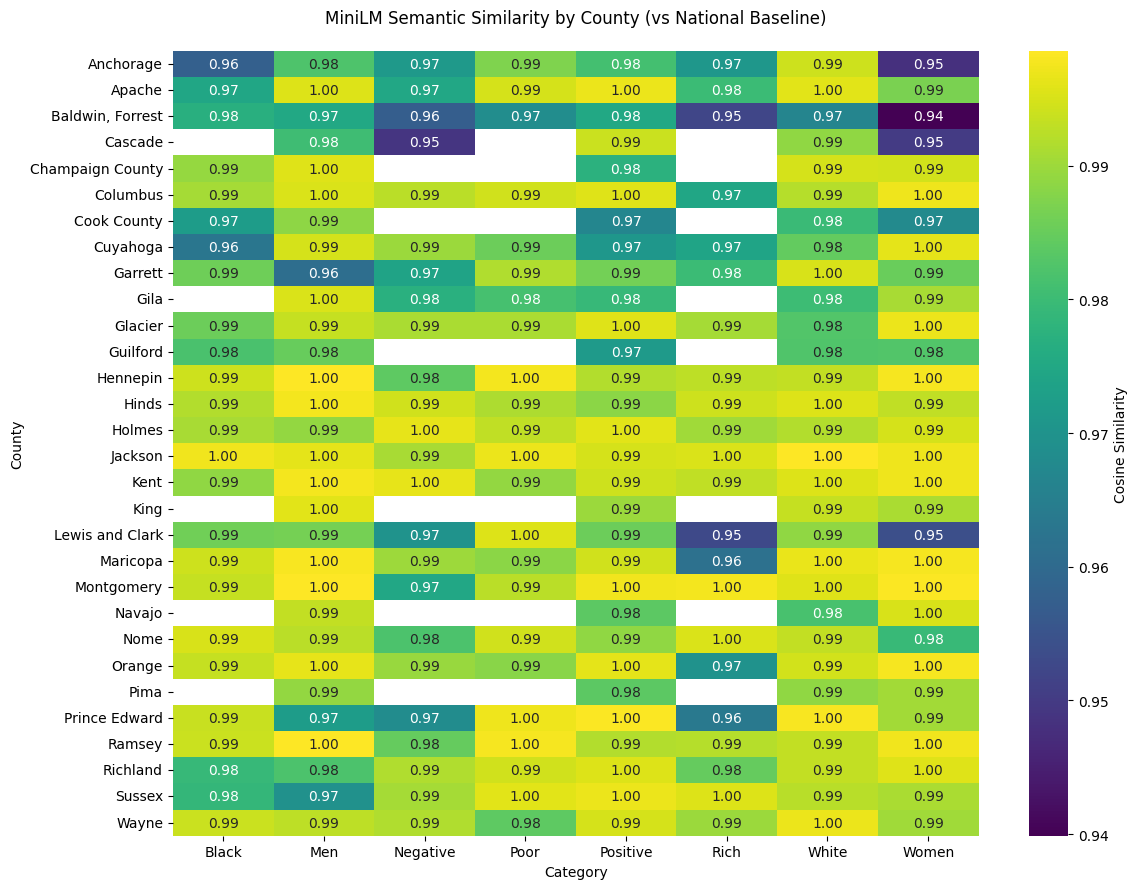

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the plotting function
def plot_similarity_heatmap(scores_df, location_col, title):
    """Plots a heatmap of cosine similarities by location and category."""
    if scores_df.empty:
        print(f"Warning: No data to plot for {location_col} heatmap.")
        return

    # Pivot the dataframe so locations are rows and categories are columns
    pivot_df = scores_df.pivot(index=location_col, columns="category", values="cosine_to_global")

    # Drop rows that are entirely NaN to keep the plot clean
    pivot_df = pivot_df.dropna(how='all')

    # Auto-scale height based on the number of rows
    plt.figure(figsize=(12, max(8, len(pivot_df) * 0.3)))

    sns.heatmap(
        pivot_df,
        cmap="viridis",
        annot=True,
        fmt=".2f",
        cbar_kws={'label': 'Cosine Similarity'}
    )

    plt.title(title, pad=20)
    plt.ylabel(location_col)
    plt.xlabel("Category")
    plt.tight_layout()
    plt.show()

# 2. Load the saved CSV files
print("Loading data from CSVs...")
state_scores_df = pd.read_csv("state_minilm_token_similarity.csv")
county_scores_df = pd.read_csv("county_minilm_token_similarity.csv")

# 3. Generate the plots
print("Plotting State Heatmap...")
plot_similarity_heatmap(
    state_scores_df,
    "State",
    "MiniLM Semantic Similarity by State (vs National Baseline)"
)

print("Plotting County Heatmap...")
plot_similarity_heatmap(
    county_scores_df,
    "County",
    "MiniLM Semantic Similarity by County (vs National Baseline)"
)